In [4]:
### Load the data

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the JSON responses
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/results/results_with_uq/llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the DataFrame with correct answers
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]

# Extract the answers from the DataFrame
true_answers = dict(zip(range(2787, 2866), df['answer']))

### Binwise calculate accuracy 

In [ ]:
# Initialize lists to store uncertainties and accuracies
confidences = []
accuracies = []

# Extract data from responses_with_uncertainty
key_to_check_similarity = 'avg_similarity_within_group'
for idx, result in tqdm(responses_with_uncertainty.items()):
    if key_to_check_similarity not in result and len(result['responses']) == 0:
        continue
    elif len(result['responses']) != 0:
        responses = result['responses']
        confidence = result[key_to_check_similarity]
        true_answer = true_answers.get(int(idx))

        # correct = sum(response['answer'] == true_answer for response in responses)
        correct = 0
        for response in responses:
            try:
                if isinstance(response, dict) and response['answer'] == true_answer:
                    correct += 1
            except KeyError:
                print(f"Response {response} does not contain 'answer' key. Skipping this response.")
            except TypeError:
                print(f"Unexpected data type in response: {response}. Skipping this response.")
        avg_accuracy = correct / len(responses)
        
        confidences.append(confidence)
        accuracies.append(avg_accuracy)

# Convert lists to NumPy arrays and handle NaNs
confidences = np.array(confidences)
accuracies = np.array(accuracies)

# Remove NaNs
confidences_copy = confidences.copy()
confidences = confidences[~np.isnan(confidences_copy)]
accuracies = accuracies[~np.isnan(confidences_copy)]

### Plot Uncertainy vs Accuracy ( Bin data by uncertainty )

In [ ]:
# Bin data by uncertainty
def bin_data(confidences, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_accuracies = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_accuracies.append(np.mean(accuracies[bin_mask]))
        else:
            bin_accuracies.append(0)  # If no data points fall in the bin, set accuracy to 0

        # Debugging: Print bin details
        print(f"Bin {i}: Center = {bin_centers[i]:.2f}, Accuracy = {bin_accuracies[-1]:.2f}, Count = {np.sum(bin_mask)}")

    return bin_centers, bin_accuracies

# Plot the calibration curve
def plot_calibration_curve(confidences, accuracies, num_bins=10):
    bin_centers, bin_accuracies = bin_data(confidences, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Consistency with Group by Graph Similarity Reliability Curve: Confidence vs. Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the calibration curve
plot_calibration_curve(confidences, accuracies, num_bins=10)

### Plot Uncertainty vs confidence ( Bin by confidence )

100%|██████████| 80/80 [00:00<00:00, 59314.89it/s]

Response {'question': 'Which caption accurately orders car features (tub, flags, roof) and other contextual information (event/year, location)?', 'options': ['A', 'C', 'B', 'D'], 'explanation': "This caption is correct as it incorporates all accurate features (tub on the roof, flags attached) and situates the car in context (Mongol Rally) and time (2009). It mentions the car being decorated with flames, which is a car feature, but without a clear picture, it's not possible to validate this from the image. Additionally, it correctly places the year and event as the Mongol Rally in 2009."} does not contain 'answer' key. Skipping this response.
Response {'explanation': "The given image has cars lined up with decals and a racing theme, likely for the Mongol Rally. The caption that accurately reflects this scenario is 'C. With a tub resting on its outer roof, flags attached, the car is ready to take off for the rally.' This is because of the specific detail of the tub on the roof and the fl

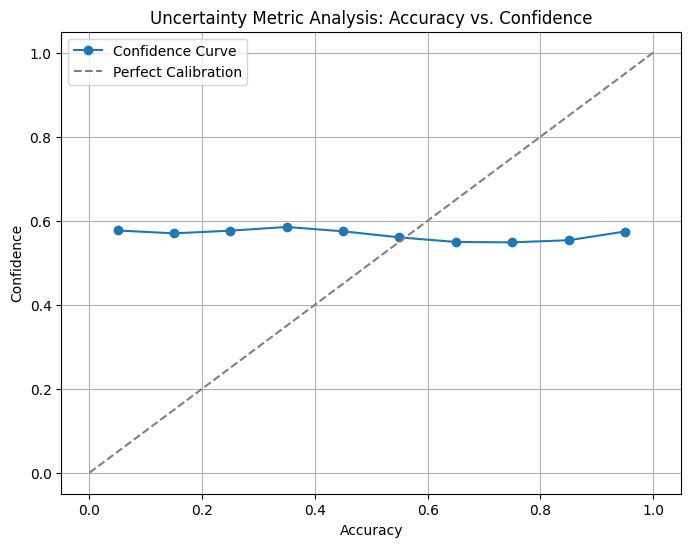

In [9]:
# Initialize lists to store uncertainties and accuracies
confidences = []
accuracies = []

# Extract data from responses_with_uncertainty
key_to_check_similarity = 'uncertainty'
for idx, result in tqdm(responses_with_uncertainty.items()):
    if key_to_check_similarity not in result and len(result['responses']) == 0:
        continue
    elif len(result['responses']) != 0:
        responses = result['responses']
        if key_to_check_similarity.lower() == 'uncertainty':
            confidence = 1 - result[key_to_check_similarity]
        else:
            confidence = result[key_to_check_similarity]
        true_answer = true_answers.get(int(idx))

        # correct = sum(response['answer'] == true_answer for response in responses)
        correct = 0
        for response in responses:
            try:
                if isinstance(response, dict) and response['answer'] == true_answer:
                    correct += 1
            except KeyError:
                print(f"Response {response} does not contain 'answer' key. Skipping this response.")
            except TypeError:
                print(f"Unexpected data type in response: {response}. Skipping this response.")
        avg_accuracy = correct / len(responses)
        
        confidences.append(confidence)
        accuracies.append(avg_accuracy)

# Convert lists to NumPy arrays and handle NaNs
confidences = np.array(confidences)
accuracies = np.array(accuracies)

# Remove NaNs
accuracies_copy = accuracies.copy()
accuracies = accuracies[~np.isnan(accuracies_copy)]
confidences = confidences[~np.isnan(accuracies_copy)]

# Bin data by accuracy
def bin_data_by_accuracy(accuracies, confidences, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(accuracies, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_confidences = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_confidences.append(np.mean(confidences[bin_mask]))
        else:
            bin_confidences.append(0)  # If no data points fall in the bin, set confidence to 0

        # Debugging: Print bin details
        print(f"Bin {i}: Center = {bin_centers[i]:.2f}, Confidence = {bin_confidences[-1]:.2f}, Count = {np.sum(bin_mask)}")

    return bin_centers, bin_confidences

# Plot the confidence curve binned by accuracy
def plot_confidence_curve(accuracies, confidences, num_bins=10):
    bin_centers, bin_confidences = bin_data_by_accuracy(accuracies, confidences, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_confidences, marker='o', label='Confidence Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Accuracy')
    plt.ylabel('Confidence')
    plt.title('Uncertainty Metric Analysis: Accuracy vs. Confidence')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the confidence curve binned by accuracy
plot_confidence_curve(accuracies, confidences, num_bins=10)

In [13]:
# responses_with_uncertainty

### Save the keys to visualize the graphs 

100%|██████████| 80/80 [00:00<00:00, 61533.89it/s]

Response {'question': 'Which caption accurately orders car features (tub, flags, roof) and other contextual information (event/year, location)?', 'options': ['A', 'C', 'B', 'D'], 'explanation': "This caption is correct as it incorporates all accurate features (tub on the roof, flags attached) and situates the car in context (Mongol Rally) and time (2009). It mentions the car being decorated with flames, which is a car feature, but without a clear picture, it's not possible to validate this from the image. Additionally, it correctly places the year and event as the Mongol Rally in 2009."} does not contain 'answer' key. Skipping this response.
Response {'explanation': "The given image has cars lined up with decals and a racing theme, likely for the Mongol Rally. The caption that accurately reflects this scenario is 'C. With a tub resting on its outer roof, flags attached, the car is ready to take off for the rally.' This is because of the specific detail of the tub on the roof and the fl

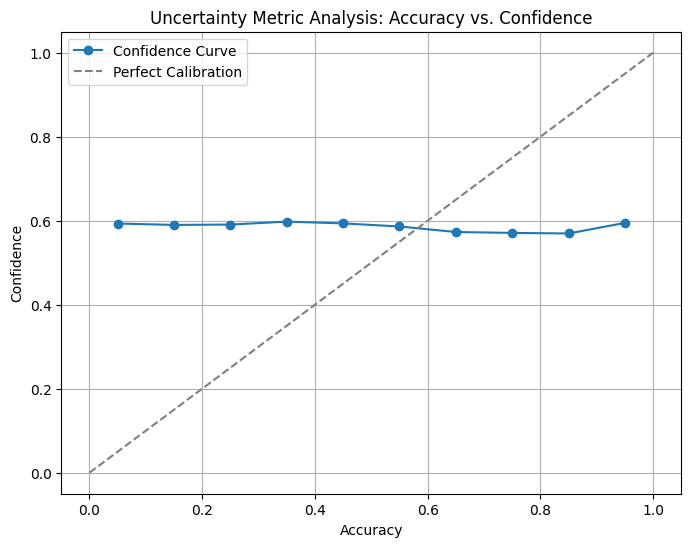

In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the JSON responses
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/results/results_with_uq/llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the DataFrame with correct answers
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]

# Extract the answers from the DataFrame
true_answers = dict(zip(range(2787, 2866), df['answer']))

# Initialize lists to store accuracies and confidences
accuracies = []
confidences = []
response_keys = []

# Extract data from responses_with_uncertainty
key_to_check_similarity = 'avg_similarity_within_group'
for idx, result in tqdm(responses_with_uncertainty.items()):
    if key_to_check_similarity not in result and len(result['responses']) == 0:
        continue
    elif len(result['responses']) != 0:
        responses = result['responses']
        confidence = result[key_to_check_similarity]
        true_answer = true_answers.get(int(idx))

        # correct = sum(response['answer'] == true_answer for response in responses)
        correct = 0
        for response in responses:
            try:
                if isinstance(response, dict) and response['answer'] == true_answer:
                    correct += 1
            except KeyError:
                print(f"Response {response} does not contain 'answer' key. Skipping this response.")
            except TypeError:
                print(f"Unexpected data type in response: {response}. Skipping this response.")
        avg_accuracy = correct / len(responses)
        confidences.append(confidence)
        accuracies.append(avg_accuracy)
        response_keys.append(int(idx))

# Convert lists to NumPy arrays and handle NaNs
confidences = np.array(confidences)
accuracies = np.array(accuracies)
response_keys = np.array(response_keys)

# Remove NaNs
accuracies_copy = accuracies.copy()
accuracies = accuracies[~np.isnan(accuracies_copy)]
confidences = confidences[~np.isnan(accuracies_copy)]
response_keys = response_keys[~np.isnan(accuracies_copy)]

# Bin data by accuracy
def bin_data_by_accuracy(accuracies, confidences, response_keys, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(accuracies, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_confidences = []
    bin_counts = []
    bin_keys = [[] for _ in range(num_bins)]

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_confidences.append(np.mean(confidences[bin_mask]))
            bin_counts.append(np.sum(bin_mask))
            bin_keys[i].extend(response_keys[bin_mask].tolist())
        else:
            bin_confidences.append(0)  # If no data points fall in the bin, set confidence to 0
            bin_counts.append(0)

        # Debugging: Print bin details
        print(f"Bin {i}: Center = {bin_centers[i]:.2f}, Confidence = {bin_confidences[-1]:.2f}, Count = {bin_counts[-1]}")

    # Convert to lists to ensure they are serializable
    bin_results = {
        "bin_centers": [float(center) for center in bin_centers],
        "bin_confidences": [float(conf) for conf in bin_confidences],
        "bin_counts": [int(count) for count in bin_counts],
        "bin_keys": [[int(key) for key in bin_keys] for bin_keys in bin_keys]
    }

    return bin_results

# Plot the confidence curve binned by accuracy
def plot_confidence_curve(bin_results):
    plt.figure(figsize=(8, 6))
    plt.plot(bin_results["bin_centers"], bin_results["bin_confidences"], marker='o', label='Confidence Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Accuracy')
    plt.ylabel('Confidence')
    plt.title('Uncertainty Metric Analysis: Accuracy vs. Confidence')
    plt.legend()
    plt.grid(True)
    plt.show()

# Bin data and plot the confidence curve
bin_results = bin_data_by_accuracy(accuracies, confidences, response_keys, num_bins=10)
plot_confidence_curve(bin_results)

# Convert keys to standard Python integers for JSON serialization
bin_results["bin_keys"] = [[int(key) for key in bin_keys] for bin_keys in bin_results["bin_keys"]]

# Save bin results to a JSON file
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/bin_results.json', 'w') as outfile:
    json.dump(bin_results, outfile, indent=4)
